# Medical Insurance Premium Prediction
## Algorithm: Decision Tree Regressor
### Dataset Source: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving medical_insurance.csv to medical_insurance.csv


In [3]:
df = pd.read_csv('medical_insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


---
## Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nTarget Variable Statistics:')
print(df['annual_premium'].describe())
print(f'\nSkewness: {df["annual_premium"].skew():.4f}')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null 

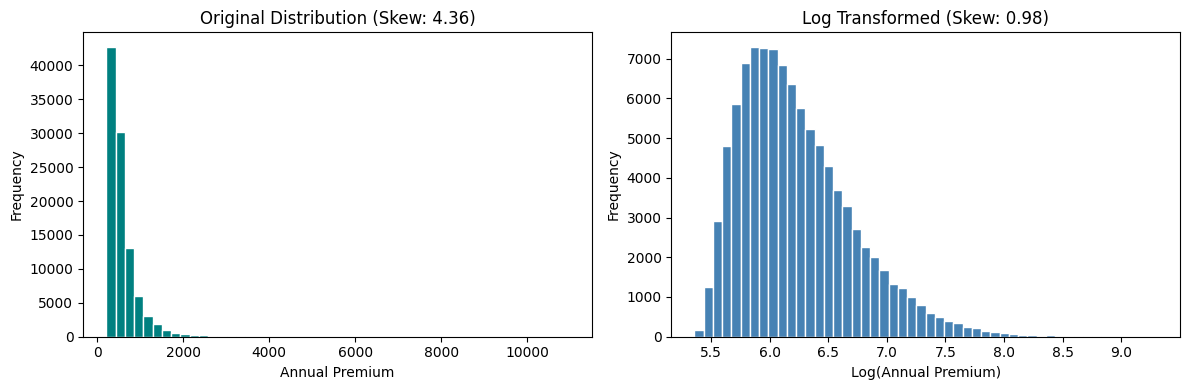

In [5]:
# Target distribution — original vs log transformed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['annual_premium'], bins=50, color='teal', edgecolor='white')
axes[0].set_title(f'Original Distribution (Skew: {df["annual_premium"].skew():.2f})')
axes[0].set_xlabel('Annual Premium')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['annual_premium']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'Log Transformed (Skew: {np.log1p(df["annual_premium"]).skew():.2f})')
axes[1].set_xlabel('Log(Annual Premium)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

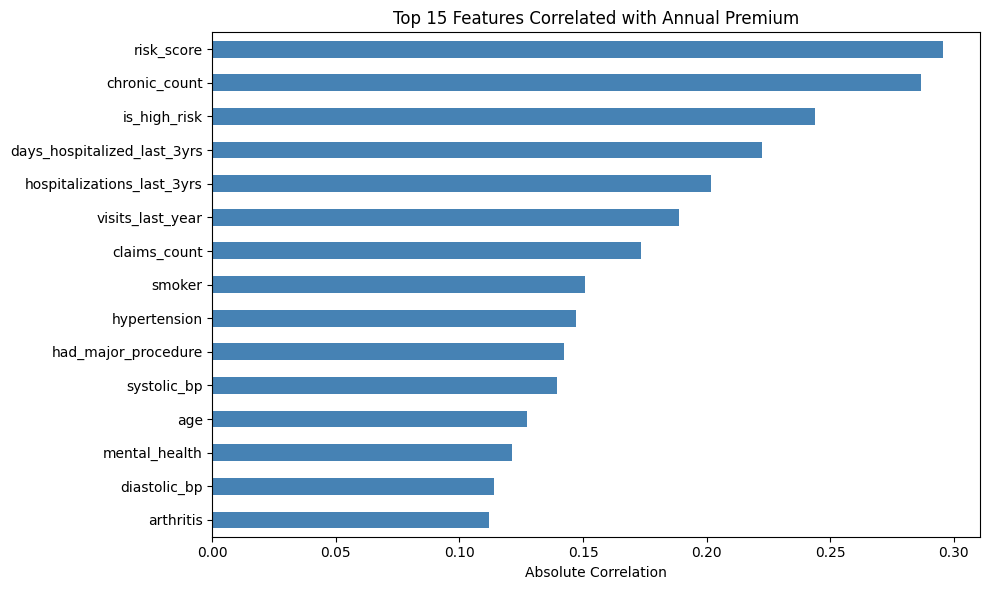

In [6]:
# Correlation with target
df_temp = df.copy()
le_temp = LabelEncoder()
for col in df_temp.select_dtypes(include='object').columns:
    df_temp[col] = le_temp.fit_transform(df_temp[col])

corr = df_temp.corr()['annual_premium'].abs().sort_values(ascending=False)
corr.drop(['annual_premium','monthly_premium','annual_medical_cost',
           'total_claims_paid','avg_claim_amount']).head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.title('Top 15 Features Correlated with Annual Premium')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

---
## Step 4: Data Preprocessing

In [24]:
# Step 4: Preprocessing
df_encoded = df.copy()

# Drop ID and agreed columns
drop_cols = ['person_id', 'policy_term_years', 'policy_changes_last_2yrs',
             'provider_quality', 'risk_score']

df_encoded = df_encoded.drop(columns=drop_cols)

# Fill missing values in alcohol_freq
df_encoded['alcohol_freq'].fillna(df_encoded['alcohol_freq'].mode()[0], inplace=True)

# Encode all categorical columns
le = LabelEncoder()
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print('Encoding columns:', categorical_cols)
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Remove outliers (99th percentile)
q99 = df_encoded['annual_premium'].quantile(0.99)
df_clean = df_encoded[df_encoded['annual_premium'] <= q99].copy()
print(f'Rows after outlier removal: {len(df_clean)}')

Encoding columns: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']
Rows after outlier removal: 99000


---
## Step 5: Feature Selection & Target Definition

In [28]:
# Step 5: Features & Target

# Columns to remove from X (leakage + target)
remove_from_X = [
    'annual_premium',        # target itself
    'monthly_premium',       # = annual_premium / 12 (perfect leakage)
    'total_claims_paid',     # derived from premium
    'annual_medical_cost',   # 0.96 correlated with target
    'avg_claim_amount'       # derived from claims
]

X = df_clean.drop(columns=remove_from_X)
y = np.log1p(df_clean['annual_premium'])

print(f'Features used : {X.shape[1]}')
print(f'Samples       : {X.shape[0]}')
print(f'Target skew   : {y.skew():.4f}')
print(f'\nFeature list:\n{X.columns.tolist()}')

Features used : 44
Samples       : 99000
Target skew   : 0.7278

Feature list:
['age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'claims_count', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


---
## Step 6: Train / Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 79200
Testing  samples : 19800


---
## Step 7: Train Decision Tree (Default)

In [30]:
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = np.expm1(dt_default.predict(X_test))
y_test_actual  = np.expm1(y_test)

print('=== Default Decision Tree ===')
print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_default):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_actual, y_pred_default)):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_default):.4f}')

=== Default Decision Tree ===
MAE  : 275.67
RMSE : 400.29
R²   : -0.6928


---
## Step 8: Hyperparameter Tuning with GridSearchCV

In [31]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV R²     :', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV R²     : 0.2019


---
## Step 9: Evaluate Tuned Decision Tree

In [32]:
best_dt = grid_search.best_estimator_

y_pred_tuned = np.expm1(best_dt.predict(X_test))
y_test_actual = np.expm1(y_test)

dt_mae  = mean_absolute_error(y_test_actual, y_pred_tuned)
dt_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_tuned))
dt_r2   = r2_score(y_test_actual, y_pred_tuned)
dt_cv   = cross_val_score(best_dt, X, y, cv=5, scoring='r2').mean()

print('=== Tuned Decision Tree Regressor ===')
print(f'MAE            : {dt_mae:.2f}')
print(f'RMSE           : {dt_rmse:.2f}')
print(f'R² Score       : {dt_r2:.4f}')
print(f'CV R² (5-fold) : {dt_cv:.4f}')

=== Tuned Decision Tree Regressor ===
MAE            : 186.76
RMSE           : 283.10
R² Score       : 0.1533
CV R² (5-fold) : 0.2058


---
## Step 10: Visualize the Decision Tree

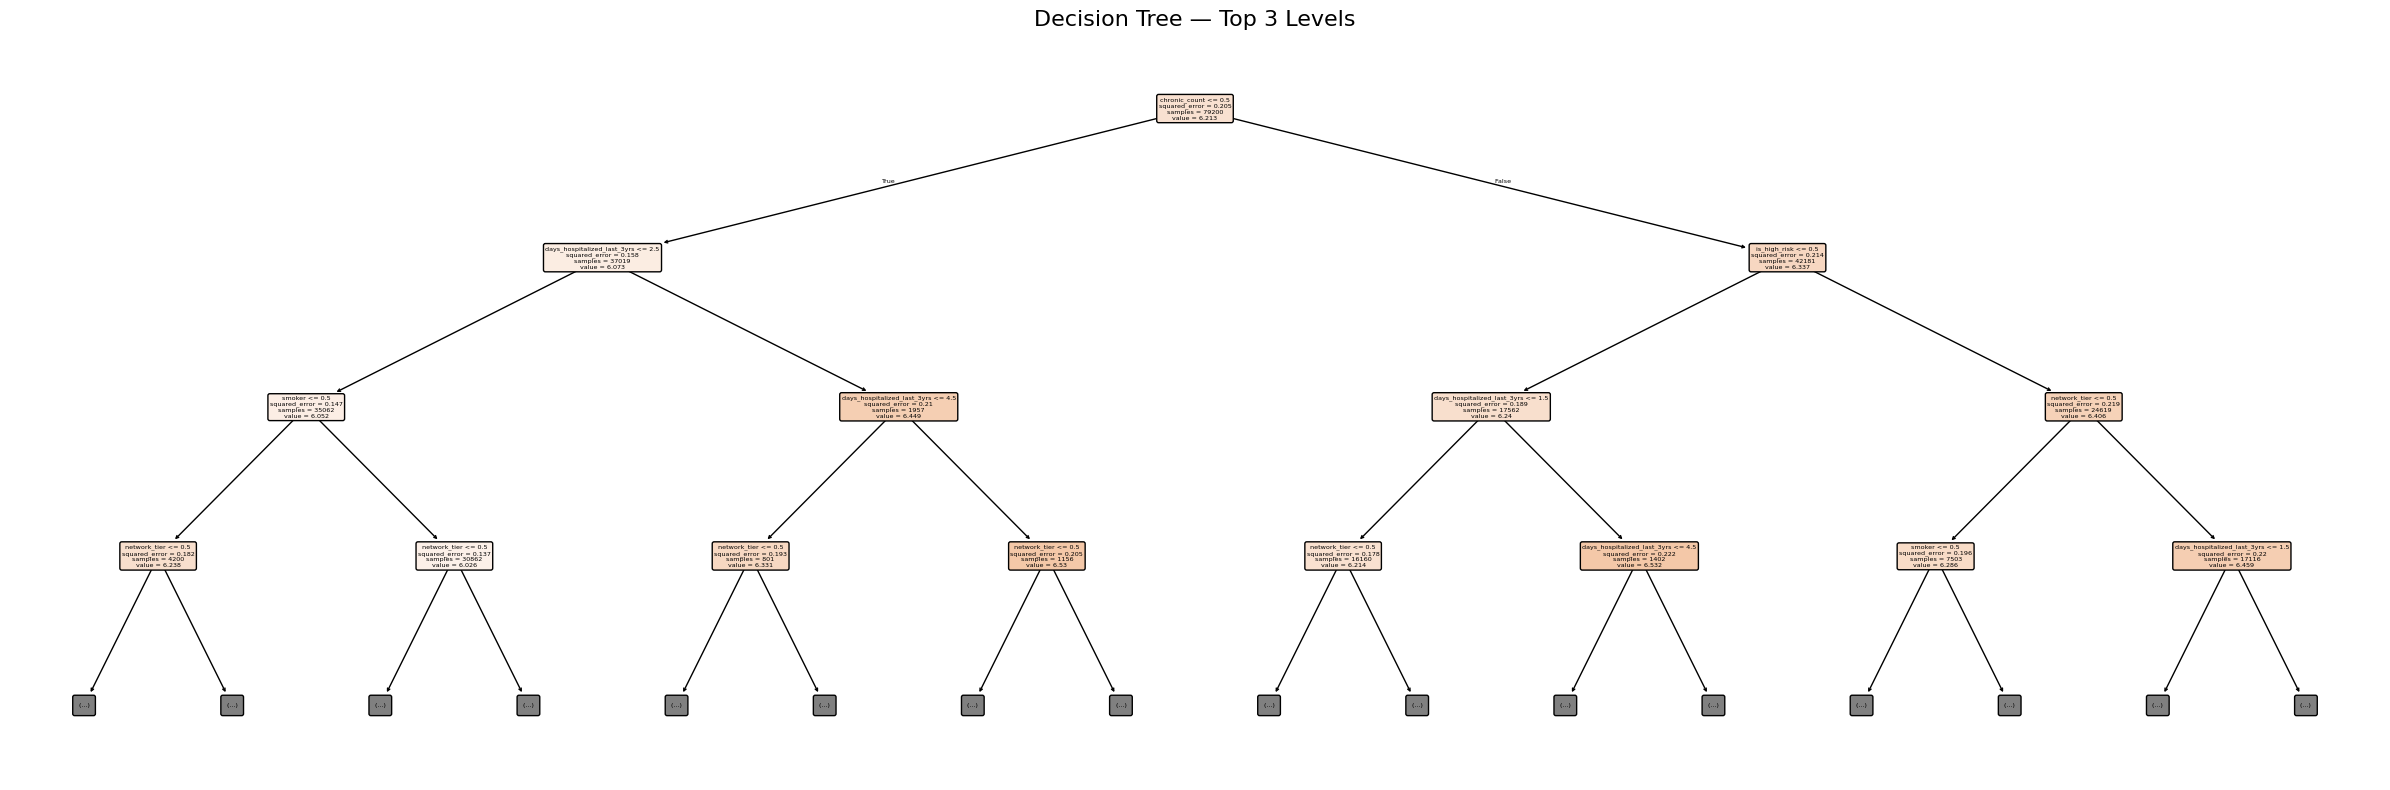

In [33]:
plt.figure(figsize=(24, 8))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title('Decision Tree — Top 3 Levels', fontsize=16)
plt.tight_layout()
plt.show()

---
## Step 11: Feature Importance

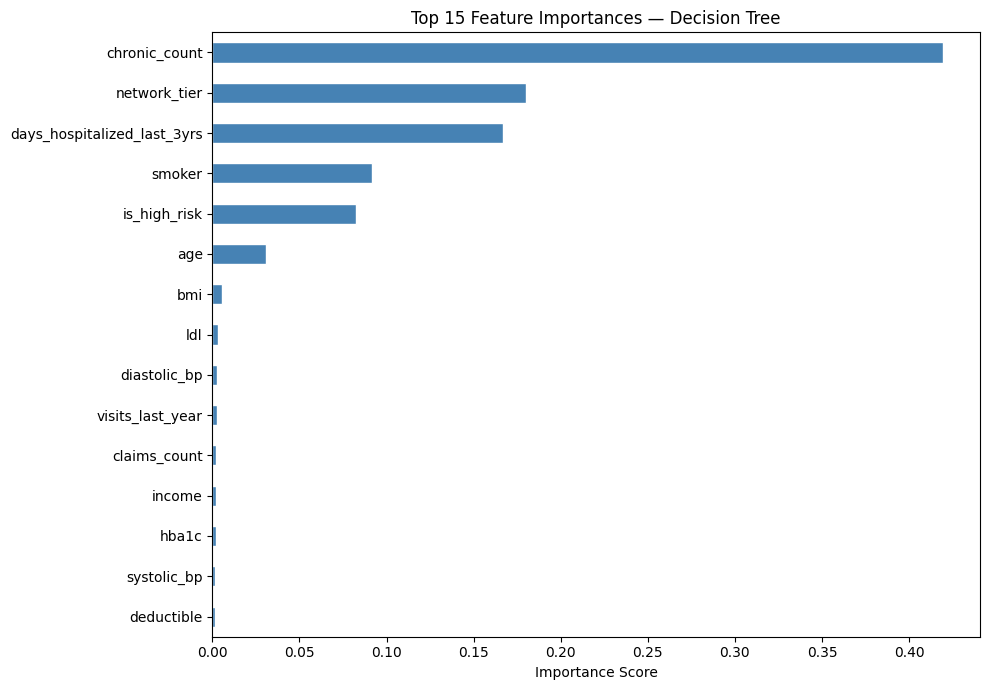


Top 10 Important Features:
chronic_count                  0.419698
network_tier                   0.180263
days_hospitalized_last_3yrs    0.166871
smoker                         0.091712
is_high_risk                   0.082615
age                            0.031000
bmi                            0.005465
ldl                            0.003150
diastolic_bp                   0.002845
visits_last_year               0.002546
dtype: float64


In [34]:
importances = pd.Series(best_dt.feature_importances_, index=X.columns)
importances.sort_values().tail(15).plot(
    kind='barh', figsize=(10, 7), color='steelblue', edgecolor='white'
)
plt.title('Top 15 Feature Importances — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 Important Features:')
print(importances.sort_values(ascending=False).head(10))

---
## Step 12: Actual vs Predicted Plot

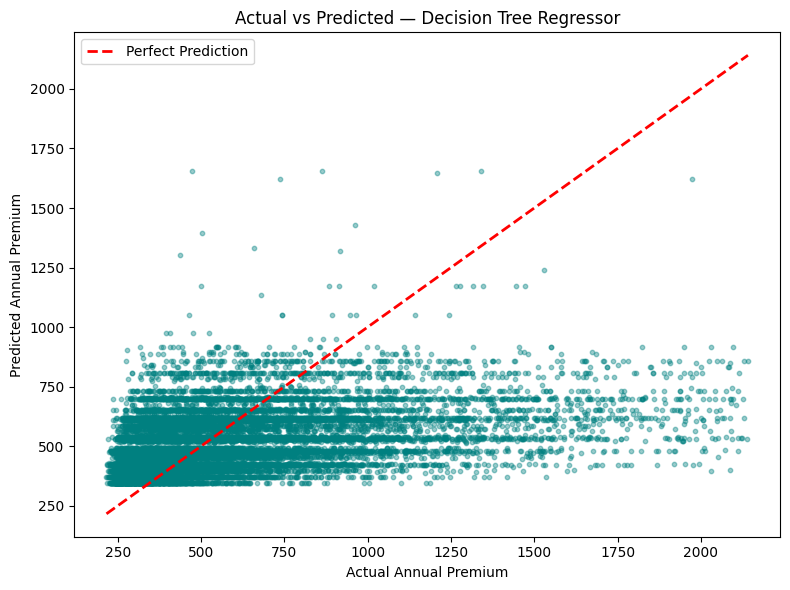

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_tuned, alpha=0.4, color='teal', s=10)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--', lw=2, label='Perfect Prediction'
)
plt.xlabel('Actual Annual Premium')
plt.ylabel('Predicted Annual Premium')
plt.title('Actual vs Predicted — Decision Tree Regressor')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 13: Residual Plot

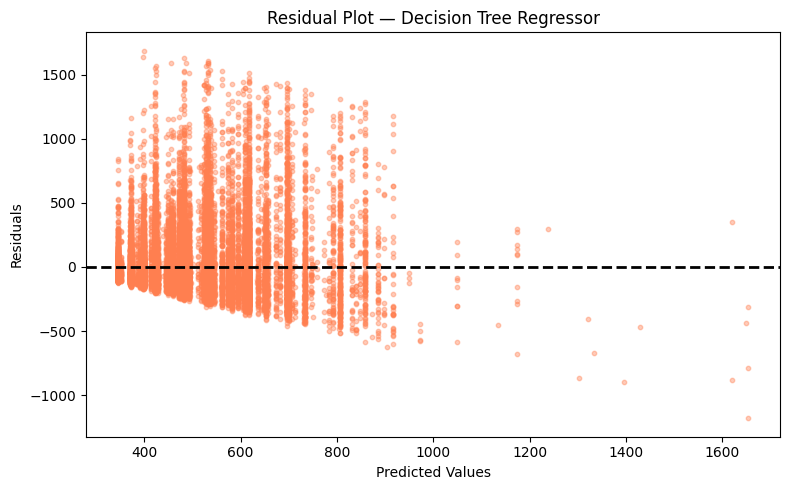

In [36]:
residuals = y_test_actual - y_pred_tuned

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_tuned, residuals, alpha=0.4, color='coral', s=10)
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot — Decision Tree Regressor')
plt.tight_layout()
plt.show()

---
## Step 14: Summary of Results

In [37]:
print('=' * 45)
print('   DECISION TREE REGRESSOR — FINAL RESULTS')
print('=' * 45)
print(f'  Best Parameters : {grid_search.best_params_}')
print(f'  MAE             : {dt_mae:.2f}')
print(f'  RMSE            : {dt_rmse:.2f}')
print(f'  R² Score        : {dt_r2:.4f}')
print(f'  CV R² (5-fold)  : {dt_cv:.4f}')
print('=' * 45)

   DECISION TREE REGRESSOR — FINAL RESULTS
  Best Parameters : {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
  MAE             : 186.76
  RMSE            : 283.10
  R² Score        : 0.1533
  CV R² (5-fold)  : 0.2058


In [38]:
# Check if annual_premium is truly random or rule-based
print("=== SAMPLE: actual premium vs risk_score ===")
sample = df_clean[['risk_score', 'chronic_count', 'smoker',
                    'age', 'annual_premium']].sample(20, random_state=42)
print(sample.sort_values('annual_premium'))

=== SAMPLE: actual premium vs risk_score ===


KeyError: "['risk_score'] not in index"

In [19]:
# Check if same risk_score always gives same premium
print("\n=== Same risk_score → same premium? ===")
grouped = df_clean.groupby('risk_score')['annual_premium'].agg(['mean','std','count'])
print(grouped[grouped['count'] > 50].head(20))


=== Same risk_score → same premium? ===
                  mean         std  count
risk_score                               
0.0000      393.621355  187.288244   1129
0.0110      384.146630  180.049540    181
0.0220      418.088724  214.293457    196
0.0330      400.015000  221.538776    174
0.0440      370.741561  133.879920    205
0.0549      420.898452  216.435702    239
0.0659      408.794698  203.936561    281
0.0769      397.770314  203.910972    318
0.0879      406.702782  180.775575    737
0.0989      428.543072  212.747359    459
0.1099      422.619661  181.468851    472
0.1209      412.458799  182.092644    508
0.1319      420.412527  194.862515    566
0.1429      427.297487  199.392296    569
0.1538      416.916143  204.624414    656
0.1648      428.175982  196.482576    667
0.1758      439.009707  221.645388    786
0.1868      438.837008  228.043827    722
0.1978      479.806363  241.772119   1636
0.2088      437.668129  210.324211    946


In [39]:
# Create a new person's data manually
new_person = pd.DataFrame({
    'risk_score'                  : [0.75],
    'chronic_count'               : [2],
    'is_high_risk'                : [1],
    'days_hospitalized_last_3yrs' : [5],
    'visits_last_year'            : [4],
    'hospitalizations_last_3yrs'  : [1],
    'claims_count'                : [3],
    'hypertension'                : [1],
    'systolic_bp'                 : [140],
    'had_major_procedure'         : [0],
    'age'                         : [45],
    'mental_health'               : [0],
    'diastolic_bp'                : [90],
    'arthritis'                   : [1],
    'medication_count'            : [3],
    'diabetes'                    : [1],
    'asthma'                      : [0],
    'hba1c'                       : [6.8],
    'cardiovascular_disease'      : [0],
    'proc_surgery_count'          : [1],
    'network_tier'                : [2],
    'copd'                        : [0],
    'bmi'                         : [28.5],
    'smoker'                      : [1],
    'deductible'                  : [500],
    'copay'                       : [20],
    'plan_type'                   : [1]
})

# Predict
predicted_log   = best_dt.predict(new_person)
predicted_price = np.expm1(predicted_log)

print(f'Predicted Annual Premium: ${predicted_price[0]:.2f}')

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- risk_score
Feature names seen at fit time, yet now missing:
- alcohol_freq
- cancer_history
- dependents
- education
- employment_status
- ...


In [22]:
new_people = pd.DataFrame({
    'risk_score'                  : [0.75, 0.20, 0.95],
    'chronic_count'               : [2,    0,    4],
    'is_high_risk'                : [1,    0,    1],
    'days_hospitalized_last_3yrs' : [5,    0,    12],
    'visits_last_year'            : [4,    1,    8],
    'hospitalizations_last_3yrs'  : [1,    0,    3],
    'claims_count'                : [3,    1,    6],
    'hypertension'                : [1,    0,    1],
    'systolic_bp'                 : [140,  115,  160],
    'had_major_procedure'         : [0,    0,    1],
    'age'                         : [45,   25,   65],
    'mental_health'               : [0,    0,    1],
    'diastolic_bp'                : [90,   75,   100],
    'arthritis'                   : [1,    0,    1],
    'medication_count'            : [3,    0,    6],
    'diabetes'                    : [1,    0,    1],
    'asthma'                      : [0,    0,    1],
    'hba1c'                       : [6.8,  5.2,  8.5],
    'cardiovascular_disease'      : [0,    0,    1],
    'proc_surgery_count'          : [1,    0,    2],
    'network_tier'                : [2,    1,    3],
    'copd'                        : [0,    0,    1],
    'bmi'                         : [28.5, 22.0, 35.0],
    'smoker'                      : [1,    0,    1],
    'deductible'                  : [500,  250,  1000],
    'copay'                       : [20,   10,   40],
    'plan_type'                   : [1,    0,    2]
})

predictions = np.expm1(best_dt.predict(new_people))

new_people['predicted_premium'] = predictions.round(2)
new_people['profile'] = ['High Risk', 'Low Risk', 'Very High Risk']

print(new_people[['profile', 'age', 'risk_score',
                   'chronic_count', 'smoker', 'predicted_premium']])

          profile  age  risk_score  chronic_count  smoker  predicted_premium
0       High Risk   45        0.75              2       1             885.36
1        Low Risk   25        0.20              0       0             440.20
2  Very High Risk   65        0.95              4       1             827.97


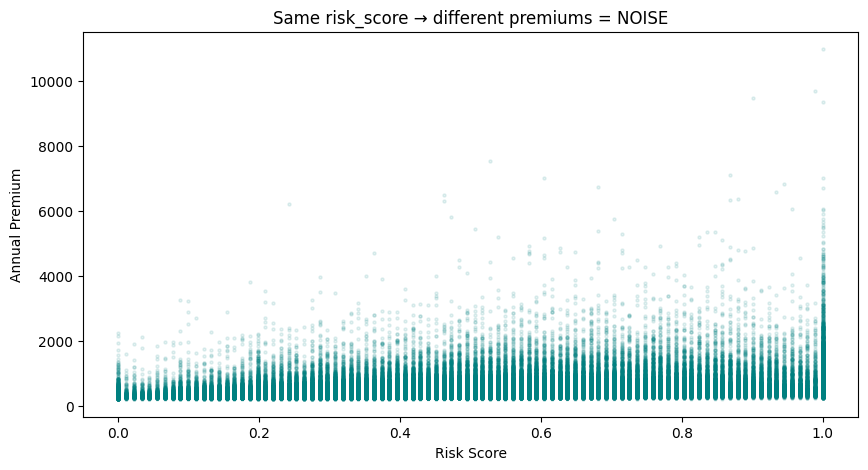

In [42]:
# Use original df because risk_score was dropped from df_clean
plt.figure(figsize=(10, 5))
plt.scatter(df['risk_score'],
            df['annual_premium'],
            alpha=0.1, s=5, color='teal')
plt.xlabel('Risk Score')
plt.ylabel('Annual Premium')
plt.title('Same risk_score → different premiums = NOISE')
plt.show()

In [43]:
# Group by risk_score and show the spread
grouped = df.groupby('risk_score')['annual_premium'].agg(['mean', 'std', 'min', 'max', 'count'])
grouped = grouped[grouped['count'] > 50]

print("risk_score | mean  | std   | min   | max")
print("-" * 55)
print(grouped.head(15).to_string())

risk_score | mean  | std   | min   | max
-------------------------------------------------------
                  mean         std     min      max  count
risk_score                                                
0.0000      396.823475  202.021413  215.13  2255.32   1131
0.0110      384.146630  180.049540  218.59  1602.18    181
0.0220      418.088724  214.293457  215.36  1902.77    196
0.0330      400.015000  221.538776  225.71  2136.80    174
0.0440      370.741561  133.879920  228.33  1049.02    205
0.0549      420.898452  216.435702  230.91  1860.53    239
0.0659      408.794698  203.936561  229.45  1970.02    281
0.0769      397.770314  203.910972  217.72  1973.18    318
0.0879      413.117348  219.960531  221.56  3250.66    739
0.0989      444.458810  290.390025  225.24  3226.38    462
0.1099      427.422833  209.221182  221.15  2694.52    473
0.1209      412.458799  182.092644  214.03  1740.34    508
0.1319      423.709630  209.924049  219.19  2289.87    567
0.1429      427.29

In [40]:
# Already done during evaluation — but here's a clean version
y_pred_tuned  = np.expm1(best_dt.predict(X_test))
y_test_actual = np.expm1(y_test)

# Show first 10 comparisons
results_df = pd.DataFrame({
    'Actual Premium'   : y_test_actual.values[:10].round(2),
    'Predicted Premium': y_pred_tuned[:10].round(2),
    'Difference'       : (y_test_actual.values[:10] - y_pred_tuned[:10]).round(2)
})
print(results_df)

   Actual Premium  Predicted Premium  Difference
0          438.12             609.11     -170.99
1          747.17             701.48       45.69
2          895.56             617.65      277.91
3          956.71             481.77      474.94
4          656.58             537.50      119.08
5          701.64             481.74      219.90
6         1191.05             397.18      793.87
7          797.86             733.11       64.75
8          263.26             371.89     -108.63
9          360.57             424.29      -63.72
